<a href="https://colab.research.google.com/github/adivar261/Othello/blob/main/Lunari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
from sklearn.datasets import make_regression


In [ ]:


# Set random seed for reproducibility
np.random.seed(0)

# Parameters
num_samples = 1000
ages = np.random.randint(13, 52, num_samples)
ethnicities = np.random.choice(['Black', 'East Asian', 'Hispanic', 'South Asian', 'White'], num_samples)
bmis = np.random.uniform(18, 25, num_samples)
phases = np.random.choice(['late luteal', 'menstruation', 'late follicular', 'mid luteal', 'ovulation'], num_samples)

# Function to generate nutrient values based on phase, age, BMI, and ethnicity
def generate_nutrient_values(menstrual_phase, age, bmi, ethnicity):
    # Base nutrient percentages that sum to 100 for each phase
    nutrient_values = {
        'MoodStable': 0,
        'Iron': 0,
        'Antioxy': 0,
        'Omega-3': 0,
        'Cramps': 0,
        'Hormonal Balance': 0,
        'Reducing Inflammation': 0,
        'Hydration': 0
    }

    # Nutritional needs by phase (percentages summing to 100)
    if menstrual_phase == 'ovulation':
        nutrient_values = {
            'MoodStable': 30,
            'Hormonal Balance': 25,
            'Omega-3': 20,
            'Hydration': 15,
            'Antioxy': 5,
            'Reducing Inflammation': 5,
            'Cramps': 0,
            'Iron': 0
        }

    elif menstrual_phase == 'late follicular':
        nutrient_values = {
            'MoodStable': 25,
            'Iron': 15,
            'Antioxy': 25,
            'Reducing Inflammation': 15,
            'Cramps': 5,
            'Hormonal Balance': 5,
            'Omega-3': 5,
            'Hydration': 5
        }

    elif menstrual_phase == 'mid luteal':
        nutrient_values = {
            'MoodStable': 25,
            'Hormonal Balance': 30,
            'Cramps': 15,
            'Hydration': 10,
            'Antioxy': 10,
            'Reducing Inflammation': 5,
            'Omega-3': 5,
            'Iron': 0
        }

    elif menstrual_phase == 'late luteal':
        nutrient_values = {
            'MoodStable': 20,
            'Iron': 15,
            'Cramps': 20,
            'Reducing Inflammation': 15,
            'Hormonal Balance': 10,
            'Omega-3': 5,
            'Hydration': 5,
            'Antioxy': 5
        }

    elif menstrual_phase == 'menstruation':
        nutrient_values = {
            'MoodStable': 15,
            'Iron': 30,
            'Cramps': 25,
            'Hydration': 10,
            'Antioxy': 10,
            'Reducing Inflammation': 5,
            'Omega-3': 5,
            'Hormonal Balance': 0
        }

    # Adjust based on age and BMI
    age_adjustment = (age - 20) * 0.5  # Simplified age factor
    bmi_adjustment = (25 - bmi) * 0.5  # Higher BMI lowers some values

    # Apply adjustments to nutrient values
    adjusted_values = {}

    for key in nutrient_values:
        adjusted_value = nutrient_values[key] + age_adjustment + bmi_adjustment
        adjusted_values[key] = max(adjusted_value, 0)  # Ensure no negative values

    # Normalize to ensure the percentages add up to 100
    total = sum(adjusted_values.values())
    if total > 0:
        for key in adjusted_values:
            adjusted_values[key] = (adjusted_values[key] / total) * 100

    return adjusted_values

# Generate data
data = []
for i in range(num_samples):
    phase = phases[i]
    nutrient_values = generate_nutrient_values(phase, ages[i], bmis[i], ethnicities[i])
    data.append([
        ages[i],
        ethnicities[i],
        round(bmis[i], 1),
        phase,
        nutrient_values['MoodStable'],
        nutrient_values['Iron'],
        nutrient_values['Antioxy'],
        nutrient_values['Omega-3'],
        nutrient_values['Cramps'],
        nutrient_values['Hormonal Balance'],
        nutrient_values['Reducing Inflammation'],
        nutrient_values['Hydration']
    ])

# Create DataFrame
columns = ['Age', 'Ethnicity', 'BMI', 'Menstrual Phase', 'MoodStable', 'Iron', 'Antioxy', 'Omega-3', 'Cramps', 'Hormonal Balance', 'Reducing Inflammation', 'Hydration']
df = pd.DataFrame(data, columns=columns)

# Save to CSV
df.to_csv('refined_menstrual_nutrition_data.csv', index=False)



# New Section

In [ ]:
#convert categorical variables into numerical format
label_encoder_ethnicity = LabelEncoder()
df['Ethnicity'] = label_encoder_ethnicity.fit_transform(df['Ethnicity'])

label_encoder_phase = LabelEncoder()
df['Menstrual Phase'] = label_encoder_phase.fit_transform(df['Menstrual Phase'])

In [ ]:
print("Known ethnicity categories:", label_encoder_ethnicity.classes_)


Known ethnicity categories: ['Black' 'East Asian' 'Hispanic' 'South Asian' 'White']


In [ ]:
# Separate features and target variables
X = df[['Age', 'Ethnicity', 'BMI', 'Menstrual Phase']]
y = df[['MoodStable', 'Iron', 'Antioxy', 'Omega-3', 'Cramps', 'Hormonal Balance', 'Reducing Inflammation', 'Hydration']]

In [ ]:
# Standardize the features using the same scaler from training
scaler = StandardScaler()
X.loc[:, ['Age', 'BMI']] = scaler.fit_transform(X[['Age', 'BMI']])

<ipython-input-50-c43586bf8708>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.66261391 -1.39905556 -1.39905556 -0.87193887  0.00658896  0.18229452
  1.50008626  0.35800009 -1.13549722  0.44585287  0.44585287 -0.60838052
 -1.57476113  1.67579183  0.35800009  0.44585287 -0.16911661  1.58793905
  0.53370565 -0.52052774 -0.95979165 -0.87193887  0.09444174 -0.25696939
 -1.22335    -0.34482217 -1.66261391 -0.08126382  1.41223348  0.44585287
  0.88511679  0.00658896  0.00658896 -0.43267495  1.14867513 -1.57476113
 -0.87193887  1.14867513  1.06082235 -0.78408609  0.35800009  1.41223348
 -0.6962333   0.797264    1.3243807  -1.66261391 -1.66261391  1.50008626
 -1.22335     1.67579183 -0.16911661 -0.34482217 -1.31120278  1.06082235
 -1.57476113 -1.57476113  1.41223348  1.67579183 -0.6962333  -0.08126382
  0.70941122 -1.66261391 -0.43267495  1.41223348 -0.60838052  0.09444174
 -0.6962333  -1.31120278 -1.13549722 -1.3112

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train a multi-output regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate using Mean Squared Error
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
print("Mean Squared Error for each food group:", mse)

Mean Squared Error for each food group: [0.06801495 0.04807847 0.03642338 0.03769179 0.03447496 0.08640581
 0.02906416 0.01625759]


In [ ]:
# New sample data
new_data = pd.DataFrame({
    'Age': [19],
    'Ethnicity': ['South Asian'],
    'BMI': [19],
    'Menstrual Phase': ['late luteal']
})


In [ ]:
new_data['Ethnicity'] = label_encoder_ethnicity.transform(new_data['Ethnicity'])
new_data['Menstrual Phase'] = label_encoder_phase.transform(new_data['Menstrual Phase'])
new_data[['Age', 'BMI']] = scaler.transform(new_data[['Age', 'BMI']])

# Predict percentages for each food group
predicted_percentages = model.predict(new_data)
print("Predicted Food Group Percentages:", predicted_percentages)

Predicted Food Group Percentages: [[19.79810912 15.30696505  6.32467689  6.32467689 19.79810912 10.81582097
  15.30696505  6.32467689]]


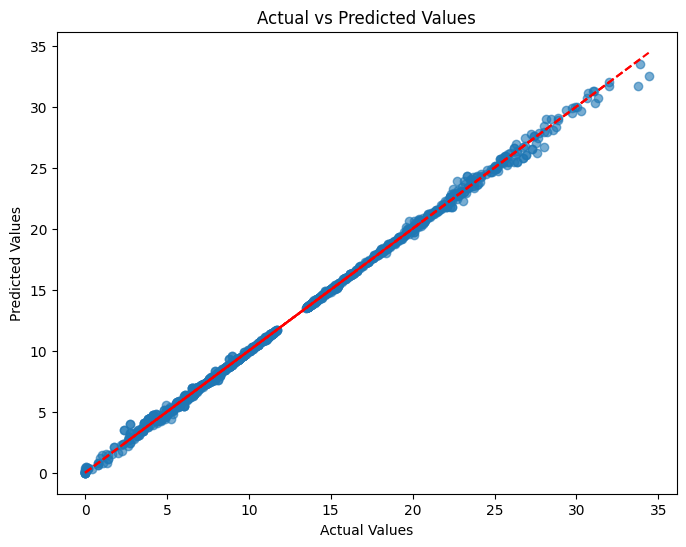

In [ ]:
#data visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE by setting squared=False
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 0.11234082037612587
Mean Squared Error (MSE): 0.04455139068610126
Root Mean Squared Error (RMSE): 0.20533350629523905
R-squared (R²): 0.9982633888584552


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Mean Squared Error: 579.67


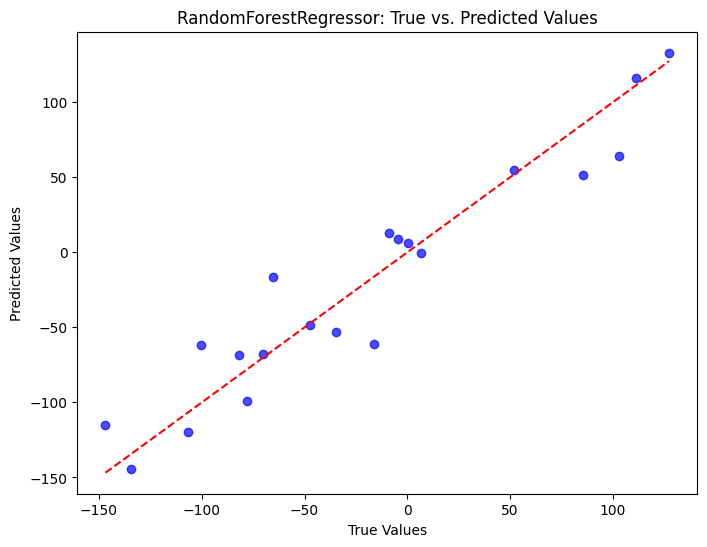

In [ ]:
X, y = make_regression(n_samples=100, n_features=4, noise=0.1, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the RandomForestRegressor
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Calculate mean squared error for performance evaluation
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Scatter plot of true vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line of perfect prediction
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("RandomForestRegressor: True vs. Predicted Values")
plt.show()